<a href="https://colab.research.google.com/github/ChiaraTagiullo/Machine_Learning_for_NLP/blob/main/01_data_exploration_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Data Exploration & Preprocessing of the Archelec Corpus

This notebook performs the first step of the NLP pipeline for the Archelec corpus.

The goals are:

1. Load and inspect the dataset.
2. Understand its structure and metadata.
3. Produce descriptive statistics.
4. Identify relevant textual fields.
5. Build a clean text representation for later NLP tasks.
6. Prepare a processed dataset for the next notebooks.



In [1]:
from google.colab import files
uploaded = files.upload()

Saving archelec_data.xlsx to archelec_data.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata
from collections import Counter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

In [3]:
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("Shape:", df.shape)
df.head()

Shape: (33031, 42)


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,identifiant de circonscription,images,pdf,ocr_url,titulaire-nom,titulaire-prenom,titulaire-sexe,titulaire-age,titulaire-age-calcule,titulaire-age-tranche,titulaire-profession,titulaire-mandat-en-cours,titulaire-mandat-passe,titulaire-associations,titulaire-autres-statuts,titulaire-soutien,titulaire-liste,titulaire-decorations,suppleant-nom,suppleant-prenom,suppleant-sexe,suppleant-age,suppleant-age-calcule,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations
0,EL009_L_1958_11_001_01_1_PF_01,1958-11-23,France;Élections législatives;Assemblée Nationale;Ve République,"Élections législatives de 1958, Ain - 01, circonscription n°01 : profession de foi de Emile Bouvard au tour 1",législatives,1,EL009,1.0,Ain,01 - Ain,1.0,https://ia800408.us.archive.org/32/items/EL009_L_1958_11_001_01_1_PF_01/EL009_L_1958_11_001_01_1_PF_01_000.jpg;https...,https://ia800408.us.archive.org/32/items/EL009_L_1958_11_001_01_1_PF_01/EL009_L_1958_11_001_01_1_PF_01.pdf,https://ia800408.us.archive.org/32/items/EL009_L_1958_11_001_01_1_PF_01/EL009_L_1958_11_001_01_1_PF_01_djvu.txt,Bouvard,Emile,homme,non mentionné,non mentionné,non mentionné,industriel biscuitier,maire;conseiller général,non mentionné,non mentionné,non mentionné,Parti radical,non mentionné,non,Brayard,Joseph,homme,non mentionné,non mentionné,non mentionné,cultivateur,maire;conseiller général,non mentionné,non mentionné,non mentionné,Parti radical,non mentionné,non
1,EL009_L_1958_11_001_01_1_PF_02,1958-11-23,France;Ve République;Élections législatives;Assemblée Nationale,"Élections législatives de 1958, Ain - 01, circonscription n°01 : profession de foi de Albert Jouvent au tour 1",législatives,1,EL009,1.0,Ain,01 - Ain,1.0,https://ia801400.us.archive.org/6/items/EL009_L_1958_11_001_01_1_PF_02/EL009_L_1958_11_001_01_1_PF_02_000.jpg;https:...,https://ia801400.us.archive.org/6/items/EL009_L_1958_11_001_01_1_PF_02/EL009_L_1958_11_001_01_1_PF_02.pdf,https://ia801400.us.archive.org/6/items/EL009_L_1958_11_001_01_1_PF_02/EL009_L_1958_11_001_01_1_PF_02_djvu.txt,Jouvent,Albert,homme,non mentionné,non mentionné,non mentionné,exploitant forestier,non mentionné,non mentionné,groupes de pression,non mentionné,Union pour la nouvelle République,non mentionné,oui,Vourlat,Noël,homme,non mentionné,non mentionné,non mentionné,cultivateur,conseiller municipal,non mentionné,non mentionné,prisonnier de guerre,Union pour la nouvelle République,non mentionné,non
2,EL009_L_1958_11_001_01_1_PF_03,1958-11-23,Élections législatives;France;Assemblée Nationale;Ve République,"Élections législatives de 1958, Ain - 01, circonscription n°01 : profession de foi de Emile Machurat au tour 1",législatives,1,EL009,1.0,Ain,01 - Ain,1.0,https://ia800806.us.archive.org/19/items/EL009_L_1958_11_001_01_1_PF_03/EL009_L_1958_11_001_01_1_PF_03_000.jpg;https...,https://ia800806.us.archive.org/19/items/EL009_L_1958_11_001_01_1_PF_03/EL009_L_1958_11_001_01_1_PF_03.pdf,https://ia800806.us.archive.org/19/items/EL009_L_1958_11_001_01_1_PF_03/EL009_L_1958_11_001_01_1_PF_03_djvu.txt,Machurat,Emile,homme,non mentionné,non mentionné,non mentionné,ouvrier,non mentionné,non mentionné,politique,résistant,Parti communiste français,non mentionné,non,Bozonnet,Georges,homme,non mentionné,non mentionné,non mentionné,cultivateur,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,non mentionné,non
3,EL009_L_1958_11_001_01_1_PF_04,1958-11-23,Élections législatives;France;Assemblée Nationale;Ve République,"Élections législatives de 1958, Ain - 01, circonscription n°01 : profession de foi de Amédée Mercier au tour 1",législatives,1,EL009,1.0,Ain,01 - Ain,1.0,https://ia802800.us.archive.org/24/items/EL009_L_1958_11_001_01_1_PF_04/EL009_L_1958_11_001_01_1_PF_04_000.jpg;https...,https://ia80

## 1. Dataset overview

The dataset contains electoral documents from the Archelec corpus.  
Each row corresponds to one electoral record, with metadata about the election, the candidate, the substitute candidate, and links to document images/PDF/OCR sources.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33031 entries, 0 to 33030
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              33031 non-null  object        
 1   date                            33031 non-null  datetime64[ns]
 2   subject                         33031 non-null  object        
 3   title                           33031 non-null  object        
 4   contexte-election               33031 non-null  object        
 5   contexte-tour                   33031 non-null  int64         
 6   cote                            33031 non-null  object        
 7   departement                     32535 non-null  float64       
 8   departement-nom                 32670 non-null  object        
 9   departement-insee               32667 non-null  object        
 10  identifiant de circonscription  31923 non-null  float64       
 11  im

In [5]:
columns_df = pd.DataFrame({
    "column": df.columns,
    "dtype": [df[col].dtype for col in df.columns],
    "n_missing": [df[col].isna().sum() for col in df.columns],
    "pct_missing": [df[col].isna().mean() * 100 for col in df.columns],
    "n_unique": [df[col].nunique(dropna=True) for col in df.columns]
})

columns_df.sort_values("pct_missing", ascending=False)

,column,dtype,n_missing,pct_missing,n_unique
12,pdf,object,1175,3.557264,31856
10,identifiant de circonscription,float64,1108,3.354425,55
34,suppleant-profession,object,1105,3.345342,4284
41,suppleant-decorations,object,1102,3.336260,2
37,suppleant-associations,object,1101,3.333232,342
40,suppleant-liste,object,1101,3.333232,1894
39,suppleant-soutien,object,1100,3.330205,2044
38,suppleant-autres-statuts,object,1100,3.330205,172
31,suppleant-age,object,1100,3.330205,135
30,suppleant-sexe,object,1100,3.330205,3


In [6]:
expected_columns = [
    "id", "date", "subject", "title", "contexte-election", "contexte-tour",
    "departement", "departement-nom", "departement-insee",
    "identifiant de circonscription",
    "titulaire-nom", "titulaire-prenom", "titulaire-sexe",
    "titulaire-profession", "titulaire-mandat-en-cours",
    "titulaire-mandat-passe", "titulaire-associations",
    "titulaire-autres-statuts", "titulaire-soutien",
    "titulaire-liste", "titulaire-decorations"
]

missing_expected = [col for col in expected_columns if col not in df.columns]
missing_expected

[]

## 2. Temporal coverage

The variable `date` allows us to study the temporal coverage of the corpus and later analyse the evolution of political discourse across time.

In [7]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

print("Min date:", df["date"].min())
print("Max date:", df["date"].max())
print("Number of years:", df["year"].nunique())

Min date: 1958-11-23 00:00:00
Max date: 2019-05-26 00:00:00
Number of years: 25


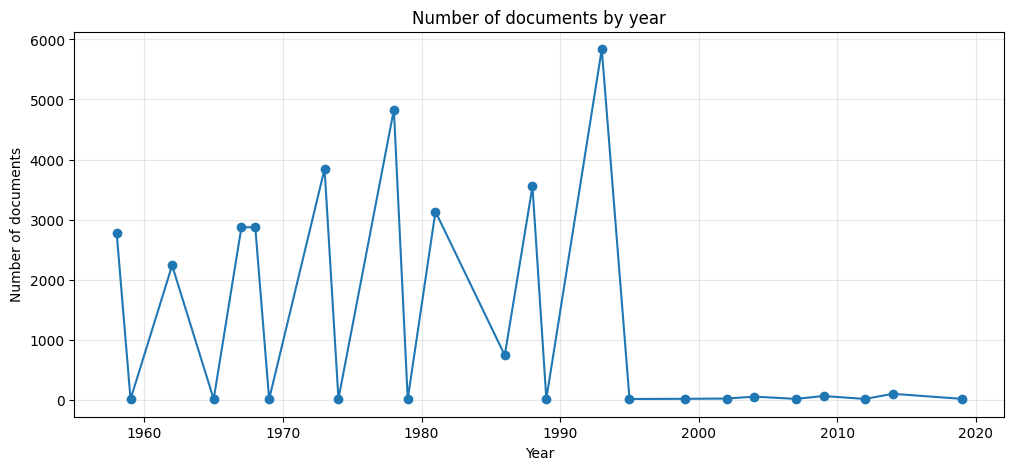

In [8]:
year_counts = df["year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values, marker="o")
plt.title("Number of documents by year")
plt.xlabel("Year")
plt.ylabel("Number of documents")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation — Temporal distribution of the corpus

The temporal distribution of documents is highly irregular. The corpus is strongly concentrated in specific years, with noticeable peaks corresponding to major electoral cycles.

In particular, the late 1970s, early 1980s, and early 1990s exhibit high document density, while many years contain very few or no documents. This suggests that the dataset is not uniformly sampled over time, but rather reflects archival availability or digitization priorities.

After the mid-1990s, the number of documents drops sharply, with only sparse observations in the 2000s and 2010s. This indicates that the corpus is primarily focused on the second half of the 20th century.

This uneven temporal coverage must be taken into account in subsequent analyses, especially for any temporal or diachronic study of political language.

In [9]:
display(df["contexte-election"].value_counts(dropna=False).to_frame("count"))
display(df["contexte-tour"].value_counts(dropna=False).to_frame("count"))

,count
contexte-election,
législatives,32626
européennes,235
présidentielle,106
régionales,25
législatives|régionales,17
législatives partielles,14
cantonales,8


,count
contexte-tour,
1,25978
2,7053


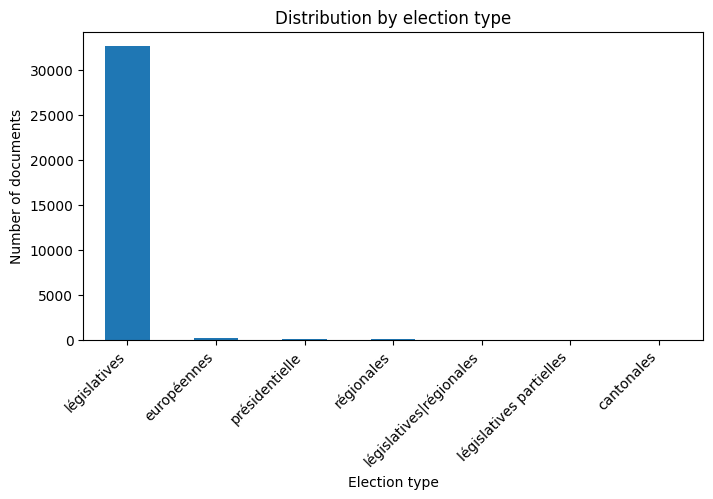

In [10]:
plt.figure(figsize=(8, 4))
df["contexte-election"].value_counts().plot(kind="bar")
plt.title("Distribution by election type")
plt.xlabel("Election type")
plt.ylabel("Number of documents")
plt.xticks(rotation=45, ha="right")
plt.show()

### Interpretation — Distribution by election type

The dataset is overwhelmingly dominated by legislative elections ("législatives"), which represent the vast majority of the documents.

Other election types (presidential, regional, European, and cantonal elections) are only marginally represented. This strong imbalance implies that the corpus primarily reflects parliamentary electoral dynamics rather than the broader electoral landscape.

As a consequence, any linguistic or political analysis derived from this dataset will largely capture patterns specific to legislative campaigns. Comparisons across election types will be limited by the small number of observations outside this category.

## 3. Geographic coverage

The corpus includes departmental metadata. This allows us to check whether the dataset is geographically balanced or concentrated in specific areas.

In [11]:
dept_counts = df["departement-nom"].value_counts(dropna=False)

display(dept_counts.head(20).to_frame("count"))

,count
departement-nom,
Paris,1863
Nord,1555
Rhône,896
Hauts-de-Seine,857
Bouches-du-Rhône,817
Pas-de-Calais,784
Seine-Maritime,744
Gironde,698
Seine-Saint-Denis,657


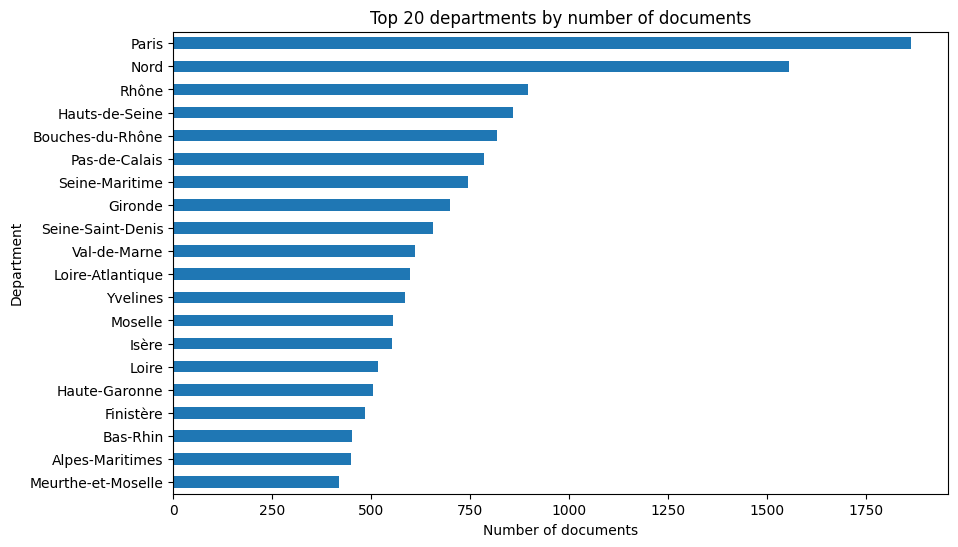

In [12]:
plt.figure(figsize=(10, 6))
dept_counts.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 departments by number of documents")
plt.xlabel("Number of documents")
plt.ylabel("Department")
plt.show()

### Interpretation — Geographic coverage

The distribution of documents across departments is highly uneven. A small number of departments, such as Paris and Nord, are strongly overrepresented, while many others appear much less frequently.

This suggests that the corpus is influenced by archival or digitization biases, possibly reflecting the availability of documents in certain regions or the historical importance of specific constituencies.

The dominance of urban and densely populated departments may also introduce a bias toward certain political profiles and discourse styles.

This geographic imbalance should be considered when interpreting patterns in political language or candidate characteristics.

## 4. Candidate metadata

Before analysing text, we inspect candidate-level metadata.  
This helps us understand which social and political information can later be used for supervised or comparative NLP analyses.

In [13]:
for col in ["titulaire-sexe", "titulaire-age-tranche", "titulaire-age-calcule"]:
    if col in df.columns:
        print("\n", col)
        display(df[col].value_counts(dropna=False).head(20).to_frame("count"))


 titulaire-sexe


,count
titulaire-sexe,
homme,29607
femme,2423
non déterminé,1001



 titulaire-age-tranche


,count
titulaire-age-tranche,
non mentionné,22472
entre 40 et 49 ans,3755
entre 30 et 39 ans,3588
entre 50 et 59 ans,1634
entre 20 et 29 ans,1202
entre 60 et 69 ans,359
entre 70 et 79 ans,20
entre 80 et 89 ans,1



 titulaire-age-calcule


,count
titulaire-age-calcule,
non mentionné,22484
42,446
43,436
38,429
40,413
35,401
37,396
45,396
39,393


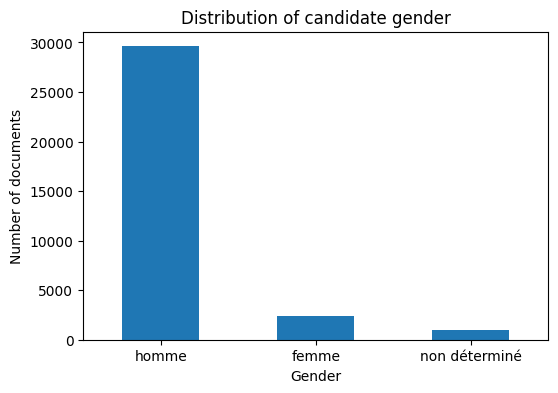

In [14]:
plt.figure(figsize=(6, 4))
df["titulaire-sexe"].value_counts(dropna=False).plot(kind="bar")
plt.title("Distribution of candidate gender")
plt.xlabel("Gender")
plt.ylabel("Number of documents")
plt.xticks(rotation=0)
plt.show()

### Interpretation — Gender imbalance

The dataset shows a strong gender imbalance, with male candidates ("homme") representing the vast majority of observations.

Female candidates ("femme") are significantly underrepresented, and a small portion of entries have undetermined gender.

This reflects historical inequalities in political representation, especially in earlier decades. As a result, linguistic patterns extracted from the corpus are likely to be dominated by male political discourse.

This limitation should be acknowledged in any interpretation of the results, particularly when discussing general properties of political language.

In [15]:
support_counts = df["titulaire-soutien"].value_counts(dropna=False)

display(support_counts.head(30).to_frame("count"))

,count
titulaire-soutien,
non mentionné,6223
Parti communiste français,4602
Parti socialiste,1823
Front national,1386
Lutte ouvrière,1076
Parti socialiste unifié,930
Rassemblement pour la République;Union pour la démocratie française,807
Rassemblement pour la République,660
Parti socialiste Section française de l'Internationale ouvrière,627


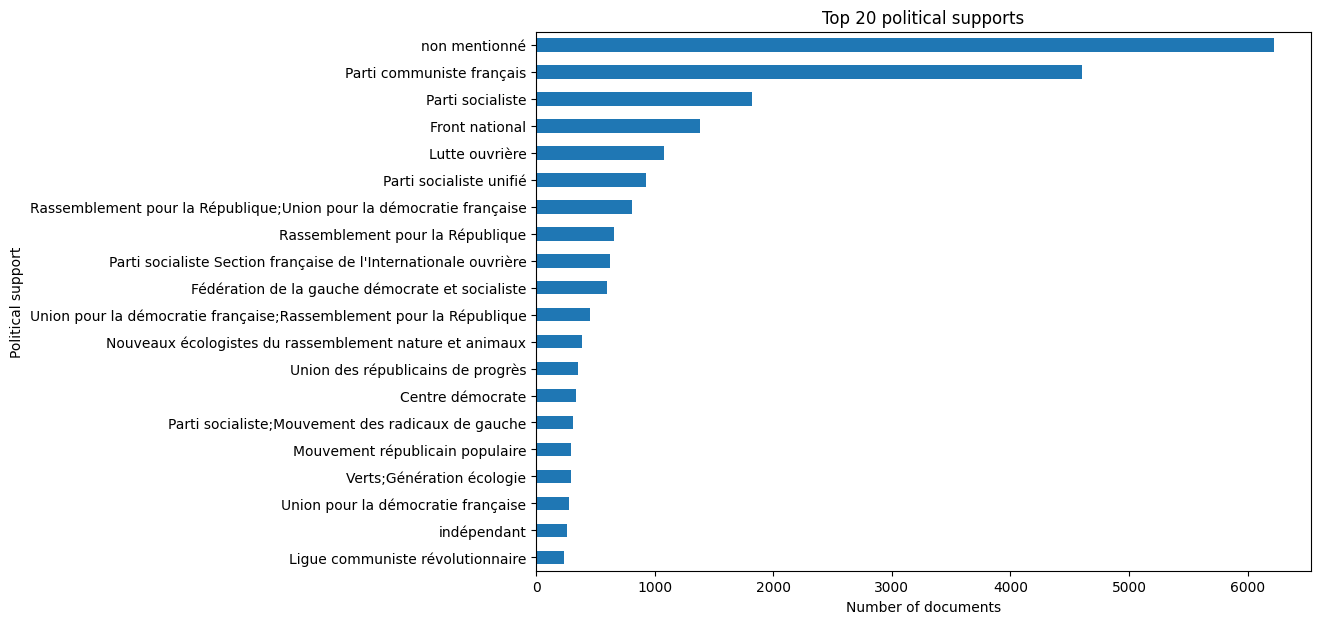

In [16]:
plt.figure(figsize=(10, 7))
support_counts.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 political supports")
plt.xlabel("Number of documents")
plt.ylabel("Political support")
plt.show()

### Interpretation — Political affiliations

A large number of entries are labeled as "non mentionné", indicating missing or unspecified political support. This suggests that the dataset contains incomplete political metadata.

Among the identified affiliations, major French political parties, such as the Communist Party, Socialist Party, and various right-wing formations, are well represented.

The diversity of party labels, including historical alliances and splinter groups, reflects the complexity of the French political landscape over time.

However, the presence of many missing values may limit the reliability of supervised classification tasks based on political affiliation.

In [17]:
profession_counts = df["titulaire-profession"].value_counts(dropna=False)

display(profession_counts.head(30).to_frame("count"))

,count
titulaire-profession,
non mentionné,14033
professeur,618
avocat,509
docteur,499
instituteur,477
ingénieur,322
agriculteur,296
chef d'entreprise,263
médecin,240


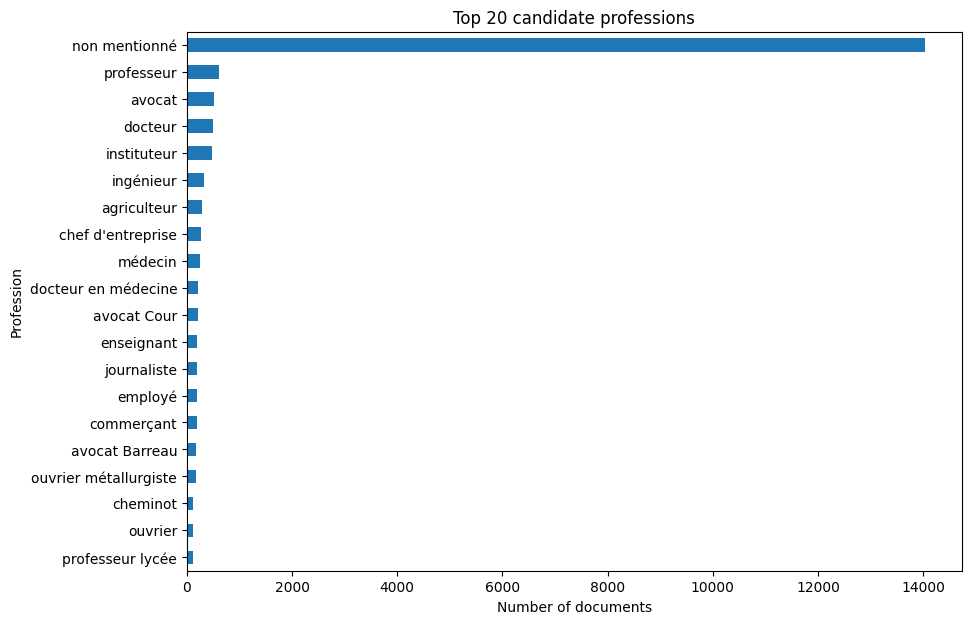

In [18]:
plt.figure(figsize=(10, 7))
profession_counts.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 candidate professions")
plt.xlabel("Number of documents")
plt.ylabel("Profession")
plt.show()

### Interpretation — Candidate professions

The most frequent category is "non mentionné", indicating that profession data is often missing or not recorded.

Among the specified professions, the dataset is dominated by highly educated and socially prestigious occupations such as professors, lawyers, doctors, and engineers.

This suggests a strong socio-professional bias in political representation, consistent with known patterns in electoral sociology.

The presence of professions such as "ouvrier" (worker) or "agriculteur" (farmer) is comparatively limited, indicating that working-class representation is less frequent in the corpus.

## 5. Textual fields

The dataset does not contain the full OCR text directly, but it includes several textual metadata fields.  
For the first NLP analyses, we construct a textual representation by combining fields such as `subject`, `title`, candidate profession, mandates, associations, political support, and other statuses.

This representation is not equivalent to the full electoral leaflet text, but it is still linguistically meaningful because it contains structured descriptions of political actors and electoral context.

In [19]:
text_columns = [
    "subject",
    "title",
    "titulaire-profession",
    "titulaire-mandat-en-cours",
    "titulaire-mandat-passe",
    "titulaire-associations",
    "titulaire-autres-statuts",
    "titulaire-soutien",
    "titulaire-liste",
    "suppleant-profession",
    "suppleant-mandat-en-cours",
    "suppleant-mandat-passe",
    "suppleant-associations",
    "suppleant-autres-statuts",
    "suppleant-soutien",
    "suppleant-liste"
]

text_columns = [col for col in text_columns if col in df.columns]
text_columns

['subject',
 'title',
 'titulaire-profession',
 'titulaire-mandat-en-cours',
 'titulaire-mandat-passe',
 'titulaire-associations',
 'titulaire-autres-statuts',
 'titulaire-soutien',
 'titulaire-liste',
 'suppleant-profession',
 'suppleant-mandat-en-cours',
 'suppleant-mandat-passe',
 'suppleant-associations',
 'suppleant-autres-statuts',
 'suppleant-soutien',
 'suppleant-liste']

In [20]:
df[text_columns].head()

,subject,title,titulaire-profession,titulaire-mandat-en-cours,titulaire-mandat-passe,titulaire-associations,titulaire-autres-statuts,titulaire-soutien,titulaire-liste,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste
0,France;Élections législatives;Assemblée Nationale;Ve République,"Élections législatives de 1958, Ain - 01, circonscription n°01 : profession de foi de Emile Bouvard au tour 1",industriel biscuitier,maire;conseiller général,non mentionné,non mentionné,non mentionné,Parti radical,non mentionné,cultivateur,maire;conseiller général,non mentionné,non mentionné,non mentionné,Parti radical,non mentionné
1,France;Ve République;Élections législatives;Assemblée Nationale,"Élections législatives de 1958, Ain - 01, circonscription n°01 : profession de foi de Albert Jouvent au tour 1",exploitant forestier,non mentionné,non mentionné,groupes de pression,non mentionné,Union pour la nouvelle République,non mentionné,cultivateur,conseiller municipal,non mentionné,non mentionné,prisonnier de guerre,Union pour la nouvelle République,non mentionné
2,Élections législatives;France;Assemblée Nationale;Ve République,"Élections législatives de 1958, Ain - 01, circonscription n°01 : profession de foi de Emile Machurat au tour 1",ouvrier,non mentionné,non mentionné,politique,résistant,Parti communiste français,non mentionné,cultivateur,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,non mentionné
3,Élections législatives;France;Assemblée Nationale;Ve République,"Élections législatives de 1958, Ain - 01, circonscription n°01 : profession de foi de Amédée Mercier au tour 1",non mentionné,maire,non mentionné,professionnel,non mentionné,non mentionné,non mentionné,greffier de paix,conseiller municipal;conseiller général,non mentionné,non mentionné,combattant,non mentionné,non mentionné
4,Ve République;Assemblée Nationale;Élections législatives;France,"Élections législatives de 1958, Ain - 01, circonscription n°01 : profession de foi de Hubert Pernin au tour 1",docteur-vétérinaire,maire;conseiller général,non mentionné,non mentionné,non mentionné,Centre national des indépendants et paysans,non mentionné,cultivateur;président Coopérative élevage,non mentionné,non mentionné,non mentionné,non mentionné,Centre national des indépendants et paysans,non mentionné


In [21]:
def combine_text_fields(row, columns):
    values = []
    for col in columns:
        value = row[col]
        if pd.notna(value):
            value = str(value).strip()
            if value.lower() not in ["", "nan", "non mentionné"]:
                values.append(value)
    return " ; ".join(values)

df["text_raw"] = df.apply(lambda row: combine_text_fields(row, text_columns), axis=1)

df[["id", "text_raw"]].head(10)

,id,text_raw
0,EL009_L_1958_11_001_01_1_PF_01,"France;Élections législatives;Assemblée Nationale;Ve République ; Élections législatives de 1958, Ain - 01, circonsc..."
1,EL009_L_1958_11_001_01_1_PF_02,"France;Ve République;Élections législatives;Assemblée Nationale ; Élections législatives de 1958, Ain - 01, circonsc..."
2,EL009_L_1958_11_001_01_1_PF_03,"Élections législatives;France;Assemblée Nationale;Ve République ; Élections législatives de 1958, Ain - 01, circonsc..."
3,EL009_L_1958_11_001_01_1_PF_04,"Élections législatives;France;Assemblée Nationale;Ve République ; Élections législatives de 1958, Ain - 01, circonsc..."
4,EL009_L_1958_11_001_01_1_PF_05,"Ve République;Assemblée Nationale;Élections législatives;France ; Élections législatives de 1958, Ain - 01, circonsc..."
5,EL009_L_1958_11_001_01_1_PF_06,"Ve République;Assemblée Nationale;Élections législatives;France ; Élections législatives de 1958, Ain - 01, circonsc..."
6,EL009_L_1958_11_001_01_1_PF_07,"Ve République;Assemblée Nationale;France;Élections législatives ; Élections législatives de 1958, Ain - 01, circonsc..."
7,EL009_L_1958_11_001_02_1_PF_01,"France;Assemblée Nationale;Ve République;Élections législatives ; Élections législatives de 1958, Ain - 01, circonsc..."
8,EL009_L_1958_11_001_02_1_PF_02,"Ve République;Assemblée Nationale;Élections législatives;France ; Élections législatives de 1958, Ain - 01, circonsc..."
9,EL009_L_1958_11_001_02_1_PF_03,"Assemblée Nationale;Ve République;France;Élections législatives ; Élections législatives de 1958, Ain - 01, circonsc..."


## 6. Basic text statistics

We now compute simple document-level statistics: number of characters, number of words, and number of unique words.  
These descriptive statistics are useful for identifying outliers and understanding the textual signal available in the corpus.

In [22]:
df["n_chars"] = df["text_raw"].str.len()
df["n_words_raw"] = df["text_raw"].str.split().apply(len)

df[["n_chars", "n_words_raw"]].describe()

,n_chars,n_words_raw
count,33031.000000,33031.000000
mean,337.209349,46.391693
std,87.425986,11.112455
min,131.000000,19.000000
25%,279.000000,38.000000
50%,327.000000,46.000000
75%,381.000000,53.000000
max,1080.000000,126.000000


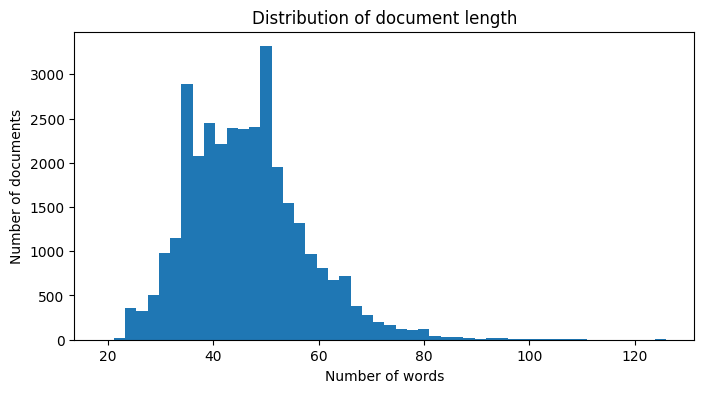

In [23]:
plt.figure(figsize=(8, 4))
plt.hist(df["n_words_raw"], bins=50)
plt.title("Distribution of document length")
plt.xlabel("Number of words")
plt.ylabel("Number of documents")
plt.show()

### Interpretation — Document length distribution

The distribution of document length is relatively concentrated, with most documents containing between approximately 30 and 60 words.

This confirms that the constructed textual representation, based on metadata fields, is relatively short and structured, rather than long-form political discourse.

A small number of longer documents exist, but they remain rare. This limited textual length may constrain the richness of certain NLP methods, such as topic modeling, while still being suitable for frequency-based and classification approaches.

In [24]:
df.sort_values("n_words_raw", ascending=False)[["id", "date", "title", "text_raw", "n_words_raw"]].head(10)

,id,date,title,text_raw,n_words_raw
1882,EL011_L_1958_11_086_03_1_PF_01,1958-11-23,"Élections législatives de 1958, Vienne - 86, circonscription n°03 : profession de foi de Claude Peyret au tour 1","Élections législatives;Assemblée Nationale;France;Ve République ; Élections législatives de 1958, Vienne - 86, circo...",126
2739,EL011_L_1958_11_086_03_2_PF_01,1958-11-30,"Élections législatives de 1958, Vienne - 86, circonscription n°03 : profession de foi de Claude Peyret au tour 2","Assemblée Nationale;France;Élections législatives;Ve République ; Élections législatives de 1958, Vienne - 86, circo...",126
621,EL009_L_1958_11_034_01_1_PF_06,1958-11-23,"Élections législatives de 1958, Hérault - 34, circonscription n°01 : profession de foi de Serge Lafeuillade au tour 1","Assemblée Nationale;France;Élections législatives;Ve République ; Élections législatives de 1958, Hérault - 34, circ...",125
111,EL009_L_1958_11_008_02_1_PF_01,1958-11-23,"Élections législatives de 1958, Ardennes - 08, circonscription n°02 : profession de foi de Henri Gervois au tour 1","Assemblée Nationale;Élections législatives;France;Ve République ; Élections législatives de 1958, Ardennes - 08, cir...",121
2031,EL009_L_1958_11_008_02_2_PF_01,1958-11-30,"Élections législatives de 1958, Ardennes - 08, circonscription n°02 : profession de foi de Henri Gervois au tour 2","Élections législatives;France;Assemblée Nationale;Ve République ; Élections législatives de 1958, Ardennes - 08, cir...",121
790,EL010_L_1958_11_042_01_1_PF_05,1958-11-23,"Élections législatives de 1958, Loire - 42, circonscription n°01 : profession de foi de Marcel Boute au tour 1","Élections législatives;Assemblée Nationale;Ve République;France ; Élections législatives de 1958, Loire - 42, circon...",119
13192,EL069_L_1973_03_078_07_1_PF_01,1973-03-04,"Élections législatives de 1973, Yvelines - 78, circonscription n°07 : profession de foi de Pierre Ribes au tour 1","Élections législatives;France;Assemblée Nationale;Ve République ; Élections législatives de 1973, Yvelines - 78, cir...",118
1490,EL011_L_1958_11_069_09_1_PF_01,1958-11-23,"Élections législatives de 1958, Rhône - 69, circonscription n°09 : profession de foi de Jean Piat au tour 1","Ve République;Assemblée Nationale;Élections législatives;France ; Élections législatives de 1958, Rhône - 69, circon...",111
15578,EL103_L_1978_03_033_01_1_PF_09,1978-03-12,"Élections législatives de 1978, Gironde - 33, circonscription n°01 : profession de foi de Pierre-Armand Bedos au tour 1","Assemblée Nationale;Ve République;Élections législatives;France ; Élections législatives de 1978, Gironde - 33, circ...",110
22559,EL137_L_1981_06_094_05_2_PF_01,1981-06-21,"Élections législatives de 1981, Val-de-Marne - 94, circonscription n°05 : profession de foi de Jean-Louis Beaumont a...","Ve République;Élections législatives;France;Assemblée Nationale ; Élections législatives de 1981, Val-de-Marne - 94,...",109


## 7. Text normalization

We apply a standard preprocessing pipeline:

1. lowercasing;
2. accent normalization;
3. punctuation removal;
4. removal of digits;
5. tokenization;
6. stopword removal;
7. removal of very short tokens.

This version will be used for exploratory statistics, bag-of-words, TF-IDF, and topic modeling.

In [25]:
import nltk
nltk.download("stopwords")

from nltk.corpus import stopwords

french_stopwords = set(stopwords.words("french"))

custom_stopwords = {
    "non", "mentionne", "mentionnee", "france", "elections", "election",
    "legislatives", "legislative", "assemblee", "nationale",
    "republique", "circonscription", "tour", "candidat", "candidate",
    "titulaire", "suppleant", "suppleante"
}

stop_words = french_stopwords.union(custom_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [26]:
def normalize_text(text):
    text = str(text).lower()
    text = unicodedata.normalize("NFD", text)
    text = text.encode("ascii", "ignore").decode("utf-8")
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_and_clean(text):
    text = normalize_text(text)
    tokens = text.split()
    tokens = [
        token for token in tokens
        if token not in stop_words and len(token) > 2
    ]
    return tokens

df["tokens"] = df["text_raw"].apply(tokenize_and_clean)
df["text_clean"] = df["tokens"].apply(lambda tokens: " ".join(tokens))
df["n_words_clean"] = df["tokens"].apply(len)

df[["text_raw", "text_clean", "n_words_raw", "n_words_clean"]].head()

,text_raw,text_clean,n_words_raw,n_words_clean
0,"France;Élections législatives;Assemblée Nationale;Ve République ; Élections législatives de 1958, Ain - 01, circonsc...",ain profession foi emile bouvard industriel biscuitier maire conseiller general parti radical cultivateur maire cons...,41,18
1,"France;Ve République;Élections législatives;Assemblée Nationale ; Élections législatives de 1958, Ain - 01, circonsc...",ain profession foi albert jouvent exploitant forestier groupes pression union nouvelle cultivateur conseiller munici...,52,18
2,"Élections législatives;France;Assemblée Nationale;Ve République ; Élections législatives de 1958, Ain - 01, circonsc...",ain profession foi emile machurat ouvrier politique resistant parti communiste francais cultivateur parti communiste...,40,15
3,"Élections législatives;France;Assemblée Nationale;Ve République ; Élections législatives de 1958, Ain - 01, circonsc...",ain profession foi amedee mercier maire professionnel greffier paix conseiller municipal conseiller general combattant,38,14
4,"Ve République;Assemblée Nationale;Élections législatives;France ; Élections législatives de 1958, Ain - 01, circonsc...",ain profession foi hubert pernin docteur veterinaire maire conseiller general centre national independants paysans c...,47,22


In [27]:
empty_texts = (df["n_words_clean"] == 0).sum()

print("Documents with empty cleaned text:", empty_texts)
print("Percentage:", round(empty_texts / len(df) * 100, 2), "%")

Documents with empty cleaned text: 0
Percentage: 0.0 %


In [28]:
df[df["n_words_clean"] == 0][["id", "text_raw", "text_clean"]].head(20)

,id,text_raw,text_clean


## 8. Vocabulary analysis

We now analyse the most frequent terms in the cleaned corpus.  
This helps identify dominant lexical patterns and possible remaining stopwords.

In [29]:
all_tokens = [token for tokens in df["tokens"] for token in tokens]
word_freq = Counter(all_tokens)

word_freq_df = pd.DataFrame(word_freq.items(), columns=["word", "frequency"])
word_freq_df = word_freq_df.sort_values("frequency", ascending=False)

word_freq_df.head(30)

,word,frequency
1,profession,33046
2,foi,33031
10,parti,24968
19,union,23266
8,conseiller,20373
7,maire,17266
50,socialiste,15290
29,francais,11801
28,communiste,11594
9,general,10782


<Figure size 1000x700 with 0 Axes>

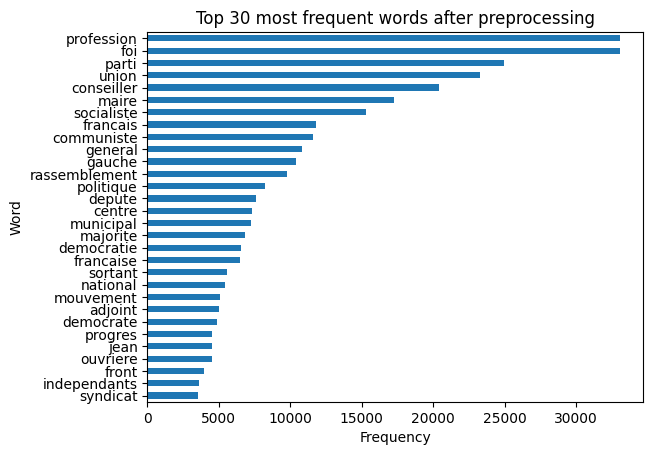

In [30]:
plt.figure(figsize=(10, 7))
word_freq_df.head(30).sort_values("frequency").plot(
    x="word",
    y="frequency",
    kind="barh",
    legend=False
)
plt.title("Top 30 most frequent words after preprocessing")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

### Interpretation — Lexical distribution

The most frequent words reflect a combination of institutional, political, and professional vocabulary.

Terms such as "parti", "union", "conseiller", and "maire" highlight the importance of political roles and organizational structures. At the same time, words like "profession" indicate the influence of structured metadata in the textual representation.

Ideological markers such as "socialiste", "communiste", and "gauche" are also prominent, suggesting that political identity is a central component of the dataset.

Overall, the vocabulary is strongly shaped by formal political descriptors rather than rhetorical or argumentative language.

In [31]:
n_tokens = len(all_tokens)
n_types = len(word_freq)
type_token_ratio = n_types / n_tokens if n_tokens > 0 else np.nan

print("Total number of tokens:", n_tokens)
print("Vocabulary size:", n_types)
print("Type-token ratio:", round(type_token_ratio, 4))

Total number of tokens: 642448
Vocabulary size: 15980
Type-token ratio: 0.0249


## 9. Zipf's law

A classical property of natural language is that word frequencies approximately follow Zipf's law.  
We verify whether the cleaned textual representation of the corpus shows this pattern.

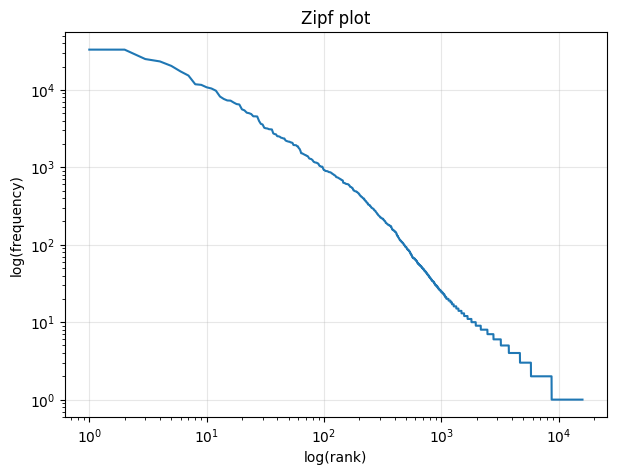

In [32]:
frequencies = np.array(sorted(word_freq.values(), reverse=True))
ranks = np.arange(1, len(frequencies) + 1)

plt.figure(figsize=(7, 5))
plt.loglog(ranks, frequencies)
plt.title("Zipf plot")
plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation — Zipf’s law

The log-log plot of word frequency versus rank follows a clear decreasing trend, consistent with Zipf’s law.

This indicates that, despite its structured nature, the corpus exhibits statistical properties typical of natural language. A small number of words are extremely frequent, while the majority occur rarely.

This confirms that standard NLP techniques based on frequency distributions (such as TF-IDF or topic modeling) are appropriate for this dataset.

## 10. N-gram analysis

Single words are useful, but political language is often expressed through multi-word expressions.  
We therefore inspect the most frequent bigrams and trigrams.

In [33]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(texts, ngram_range=(2, 2), top_n=30, min_df=5):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=0.95
    )
    X = vectorizer.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vectorizer.get_feature_names_out())
    result = pd.DataFrame({
        "ngram": vocab,
        "frequency": freqs
    }).sort_values("frequency", ascending=False)
    return result.head(top_n)

bigrams_df = get_top_ngrams(df["text_clean"], ngram_range=(2, 2), top_n=30)
trigrams_df = get_top_ngrams(df["text_clean"], ngram_range=(3, 3), top_n=30)

display(bigrams_df)
display(trigrams_df)

,ngram,frequency
6140,parti communiste,10660
1567,communiste francais,10586
6156,parti socialiste,10272
1659,conseiller general,10140
1663,conseiller municipal,7204
5057,maire conseiller,6218
2142,depute sortant,5536
3116,foi jean,4487
8454,union democratie,4118
1998,democratie francaise,4083


,ngram,frequency
7206,parti communiste francais,10586
6094,maire conseiller general,5672
8106,profession foi jean,4487
10194,union democratie francaise,4067
7301,parti socialiste unifie,2677
1382,communiste francais union,2480
4721,gauche democrate socialiste,2382
1486,conseiller general depute,2363
2922,federation gauche democrate,2359
8635,rassemblement union democratie,2040


<Figure size 1000x700 with 0 Axes>

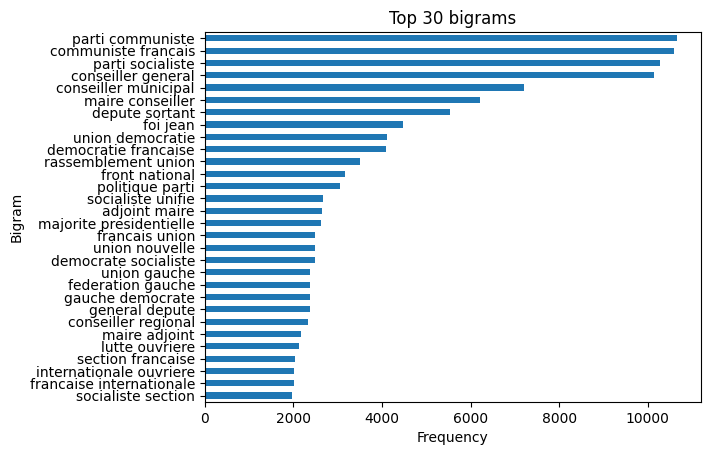

In [34]:
plt.figure(figsize=(10, 7))
bigrams_df.sort_values("frequency").plot(
    x="ngram",
    y="frequency",
    kind="barh",
    legend=False
)
plt.title("Top 30 bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()

### Interpretation — Bigrams

The most frequent bigrams correspond to political party names and institutional roles, such as "parti communiste", "parti socialiste", and "conseiller général".

These multi-word expressions capture more precise semantic units than single words and highlight the importance of political affiliations and administrative functions in the dataset.

The prominence of such bigrams confirms that much of the textual information is structured around candidate identity and institutional positioning, rather than free-form political discourse.

This suggests that n-gram-based representations will be particularly useful for downstream tasks such as classification and topic modeling.

## 11. Temporal lexical trends

We now inspect how selected terms vary over time.  
This is a preliminary step toward the later temporal analysis of political discourse.

In [35]:
keywords = [
    "communiste",
    "radical",
    "gaulliste",
    "socialiste",
    "ouvrier",
    "agriculteur",
    "maire",
    "conseiller",
    "resistant",
    "republique"
]

keyword_trends = []

for year, group in df.dropna(subset=["year"]).groupby("year"):
    tokens_year = [token for tokens in group["tokens"] for token in tokens]
    total = len(tokens_year)
    counts = Counter(tokens_year)
    for kw in keywords:
        keyword_trends.append({
            "year": year,
            "keyword": kw,
            "frequency": counts.get(kw, 0),
            "relative_frequency": counts.get(kw, 0) / total if total > 0 else 0
        })

keyword_trends_df = pd.DataFrame(keyword_trends)
keyword_trends_df.head()

,year,keyword,frequency,relative_frequency
0,1958,communiste,1092,0.019315
1,1958,radical,450,0.007959
2,1958,gaulliste,6,0.000106
3,1958,socialiste,1256,0.022216
4,1958,ouvrier,210,0.003714


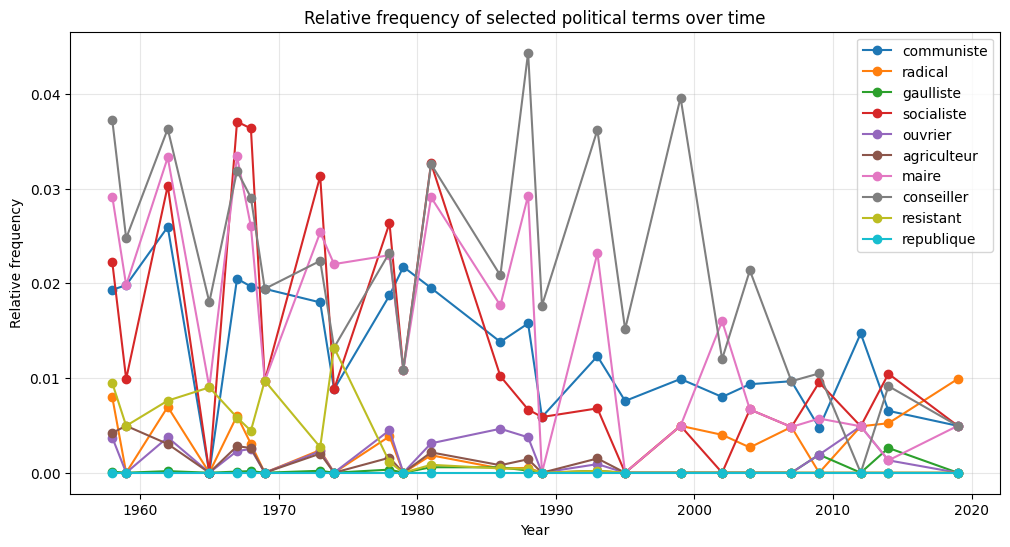

In [36]:
plt.figure(figsize=(12, 6))

for kw in keywords:
    sub = keyword_trends_df[keyword_trends_df["keyword"] == kw]
    plt.plot(sub["year"], sub["relative_frequency"], marker="o", label=kw)

plt.title("Relative frequency of selected political terms over time")
plt.xlabel("Year")
plt.ylabel("Relative frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation — Temporal evolution of political vocabulary

The temporal evolution of selected political terms reveals several interesting patterns.

First, some terms such as "communiste", "socialiste", and "radical" exhibit relatively high frequencies during earlier decades, particularly between the 1960s and 1980s. This reflects the historical prominence of these political movements in post-war France.

Second, certain terms show strong fluctuations rather than stable trends, suggesting that their presence is closely tied to specific electoral cycles or local contexts rather than long-term linguistic change.

Third, occupational and institutional terms such as "maire" and "conseiller" remain consistently present across time, indicating the structural importance of local political roles in electoral representation.

Finally, some keywords (e.g., "république") appear at very low frequency in the cleaned corpus, likely due to preprocessing choices or their limited presence in the selected textual fields.

Overall, these results suggest that the corpus captures both historical political shifts and stable institutional structures, although the irregular temporal coverage limits the possibility of drawing strong diachronic conclusions.

## 12. Preparing the dataset for the next notebooks

We save a processed version of the dataset containing:

- original metadata;
- raw combined text;
- cleaned text;
- tokenized text;
- document-level statistics.

This file will be reused for:
1. statistical text analysis;
2. TF-IDF;
3. topic modeling;
4. temporal analysis;
5. supervised classification.

In [37]:
processed_columns = [
    "id", "date", "year", "month",
    "contexte-election", "contexte-tour",
    "departement", "departement-nom", "departement-insee",
    "identifiant de circonscription",
    "titulaire-sexe", "titulaire-age", "titulaire-age-calcule",
    "titulaire-age-tranche", "titulaire-profession",
    "titulaire-mandat-en-cours", "titulaire-mandat-passe",
    "titulaire-associations", "titulaire-autres-statuts",
    "titulaire-soutien", "titulaire-liste",
    "suppleant-sexe", "suppleant-profession",
    "suppleant-mandat-en-cours", "suppleant-mandat-passe",
    "suppleant-associations", "suppleant-autres-statuts",
    "suppleant-soutien", "suppleant-liste",
    "text_raw", "text_clean", "tokens",
    "n_chars", "n_words_raw", "n_words_clean"
]

processed_columns = [col for col in processed_columns if col in df.columns]

df_processed = df[processed_columns].copy()

df_processed.to_csv("archelec_processed.csv", index=False)
df_processed.to_pickle("archelec_processed.pkl")

print("Saved files:")
print("- archelec_processed.csv")
print("- archelec_processed.pkl")

Saved files:
- archelec_processed.csv
- archelec_processed.pkl


In [38]:
files.download("archelec_processed.csv")
files.download("archelec_processed.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Preliminary conclusions

The exploratory analysis of the Archelec corpus highlights several important structural properties of the dataset.

First, the corpus is highly unbalanced across multiple dimensions. Temporally, the distribution of documents is irregular, with strong concentration in specific electoral periods, particularly between the 1960s and early 1990s. After this period, the number of documents decreases sharply, limiting the representativeness of more recent decades.

Second, the dataset is overwhelmingly dominated by legislative elections, which means that the linguistic patterns observed in the corpus primarily reflect parliamentary electoral contexts. Other types of elections are only marginally represented.

Third, the geographic and socio-demographic distributions are also skewed. Certain departments are overrepresented, and male candidates constitute the vast majority of the data. Similarly, candidate professions are biased toward highly educated and socially prestigious occupations, while many entries contain missing information.

From a textual perspective, the constructed corpus is relatively short and structured. The vocabulary is dominated by institutional, professional, and political descriptors, rather than argumentative or rhetorical language. This is further confirmed by the prevalence of bigrams corresponding to party names and official roles.

Despite this structured nature, the corpus exhibits standard statistical properties of natural language, including a Zipfian distribution of word frequencies. This supports the use of classical NLP techniques such as TF-IDF and topic modeling.

Finally, preliminary temporal analyses suggest that the corpus captures both historically specific political trends (e.g., prominence of certain parties) and stable institutional features (e.g., recurring roles such as mayor or councillor). However, the irregular temporal coverage requires careful interpretation of any diachronic results.

Overall, the Archelec corpus provides a rich but imperfect representation of political data, combining structured metadata with textual elements. This makes it particularly suitable for:

- topic modeling of political identities and affiliations;
- classification tasks based on candidate characteristics;
- analysis of institutional and socio-political structures.

At the same time, its limitations—especially missing data, short text length, and sampling biases—must be explicitly acknowledged in subsequent analyses.